## Personal notebook for Logistic Regression by Jenna Kiviaho

### For this notebook the cleaned_100k.csv was used. The same skeleton from the main notebook was copied to ensure the same pipeline for the results comparison.

**Workflow**
1. Importing needed libraries
2. Data reading and splitting (copied from main notebook)
3. Creating skeleton (copied from main notebook)
4. Creating method for MinMaxScaler using the same formula as skeleton has
7. Running the model with multiple different setups (etc. No PCA and only SMOTE, using PCA but not SMOTE)
8. Testing the effect of MinMaxScaler


### Imports

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline          # NOT sklearn's Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report,
                             ConfusionMatrixDisplay,
                             accuracy_score, f1_score)
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import PolynomialFeatures

### Reading sampled csv and splitting data 60/20/20

In [54]:
df = pd.read_csv("cleaned_100k.csv", low_memory=False)

y = df["Attack Type"]
X = df.drop("Attack Type", axis=1)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25, random_state=42, stratify=y_train_val)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (60000, 52) Val: (20000, 52) Test: (20000, 52)


### Creating skeleton

In [55]:
# # ---- Agreed 10-feature list ------------------------------------------
# FEATURES = [
#     "Flow Duration",
#     "Total Fwd Packets",
#     "Total Length of Fwd Packets",
#     "Flow Bytes/s",
#     "Flow Packets/s",
#     "Fwd Packet Length Mean",
#     "Bwd Packet Length Mean",
#     "Packet Length Mean",
#     "Packet Length Std",
#     "Average Packet Size",
# ]
# missing = [f for f in FEATURES if f not in X_train.columns]
# assert not missing, f"These features are not in the data: {missing}"

# X_train_sel = X_train[FEATURES]
# X_val_sel   = X_val[FEATURES]
# X_test_sel  = X_test[FEATURES]

# CV_FOLDS = 5
# SCORING  = "f1_macro"
# N_JOBS   = -1

# def run_experiment(clf, param_grid, label, use_smote=True, use_pca=True):
#     """Fit Pipeline+GridSearchCV and return a results dict."""
#     steps = [("scaler", StandardScaler())]
#     steps.append(("pca",   PCA() if use_pca else "passthrough"))
#     steps.append(("smote", SMOTE(random_state=42) if use_smote else "passthrough"))
#     steps.append(("clf",   clf))
#     pipe = Pipeline(steps)

#     grid = GridSearchCV(pipe, param_grid=param_grid,
#                         cv=CV_FOLDS, scoring=SCORING,
#                         n_jobs=N_JOBS, verbose=1)
#     grid.fit(X_train_sel, y_train)

#     y_val_pred  = grid.predict(X_val_sel)
#     y_test_pred = grid.predict(X_test_sel)

#     val_acc  = accuracy_score(y_val,  y_val_pred)
#     val_f1   = f1_score(y_val, y_val_pred, average="macro")
#     test_acc = accuracy_score(y_test, y_test_pred)
#     test_f1  = f1_score(y_test, y_test_pred, average="macro")

#     fig, ax = plt.subplots(figsize=(7, 6))
#     ConfusionMatrixDisplay.from_predictions(
#         y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False)
#     ax.set_title(f"{label} — test confusion matrix")
#     plt.tight_layout()
#     plt.show()

#     print(f"\n=== {label} ===")
#     print("Best params :", grid.best_params_)
#     print(f"Val  acc={val_acc:.4f}  f1_macro={val_f1:.4f}")
#     print(f"Test acc={test_acc:.4f}  f1_macro={test_f1:.4f}")
#     print(classification_report(y_test, y_test_pred, digits=3))

#     return {
#         "label":         label,
#         "best_params":   grid.best_params_,
#         "val_acc":       val_acc,
#         "val_f1_macro":  val_f1,
#         "test_acc":      test_acc,
#         "test_f1_macro": test_f1,
#         "smote":         use_smote,
#         "pca":           use_pca,
#     }

# all_results = []

In [ ]:
# Agreed 10-feature list
# Lotan skeleton
FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
]
missing = [f for f in FEATURES if f not in X_train.columns]
assert not missing, f"These features are not in the data: {missing}"

X_train_sel = X_train[FEATURES]
X_val_sel   = X_val[FEATURES]
X_test_sel  = X_test[FEATURES]

CV_FOLDS = 3
SCORING  = "f1_macro"
N_JOBS   = -1

def run_experiment(clf, param_grid, label, use_smote=True, use_pca=True, use_scaler=True, use_lda=False, use_poly=False):

    steps = []

    # 1. scaling
    if use_scaler:
        steps.append(("scaler", StandardScaler()))

    if use_poly:
        steps.append(("poly", PolynomialFeatures(degree=2))) # 29.4. added for polynomial features testing

    # 2. SMOTE (only training data)
    if use_smote:
        steps.append(("smote", SMOTE(random_state=42)))
    # 3.1 Use LDA 
    if use_lda:
        steps.append(("lda", LDA()))

    # 3.2 OR, use PCA (valinnainen)
    if use_pca:
        steps.append(("pca", PCA()))

    # 4. model
    steps.append(("clf", clf))

    pipe = Pipeline(steps)

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring=SCORING,
        n_jobs=N_JOBS,
        verbose=1
    )

    grid.fit(X_train_sel, y_train)

    y_val_pred = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average="macro")

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="macro")

    # confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False
    )
    ax.set_title(f"{label} — Test Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params:", grid.best_params_)
    print(f"Validation acc: {val_acc:.4f}, f1: {val_f1:.4f}")
    print(f"Test acc: {test_acc:.4f}, f1: {test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label": label,
        "grid": grid,
        "best_params": grid.best_params_,
        "val_acc": val_acc,
        "val_f1_macro": val_f1,
        "test_acc": test_acc,
        "test_f1_macro": test_f1,
        "smote": use_smote,
        "pca": use_pca
    }

all_results = []

### Creating minmaxscaler method

In [57]:
from sklearn.preprocessing import MinMaxScaler

# Creating method for the minmaxscaler
# Purpose is to see if it affects the results
def run_experiment_minmax(clf, param_grid, label, use_smote=True, use_pca=True, use_scaler=True, use_lda=False):

    steps = []

    # 1. scaling
    if use_scaler:
        steps.append(("scaler", MinMaxScaler()))

    # 2. SMOTE (only training data)
    if use_smote:
        steps.append(("smote", SMOTE(random_state=42)))
    # 3.1 Use LDA 
    if use_lda:
        steps.append(("lda", LDA()))

    # 3.2 OR, use PCA
    if use_pca:
        steps.append(("pca", PCA()))

    # 4. model
    steps.append(("clf", clf))

    pipe = Pipeline(steps)

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring=SCORING,
        n_jobs=N_JOBS,
        verbose=1
    )

    grid.fit(X_train_sel, y_train)

    y_val_pred = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average="macro")

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="macro")

    # confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False
    )
    ax.set_title(f"{label} — Test Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params:", grid.best_params_)
    print(f"Validation acc: {val_acc:.4f}, f1: {val_f1:.4f}")
    print(f"Test acc: {test_acc:.4f}, f1: {test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label": label,
        "grid": grid,
        "best_params": grid.best_params_,
        "val_acc": val_acc,
        "val_f1_macro": val_f1,
        "test_acc": test_acc,
        "test_f1_macro": test_f1,
        "smote": use_smote,
        "pca": use_pca
    }

### Running the model without SMOTE, scaling and PCA

Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


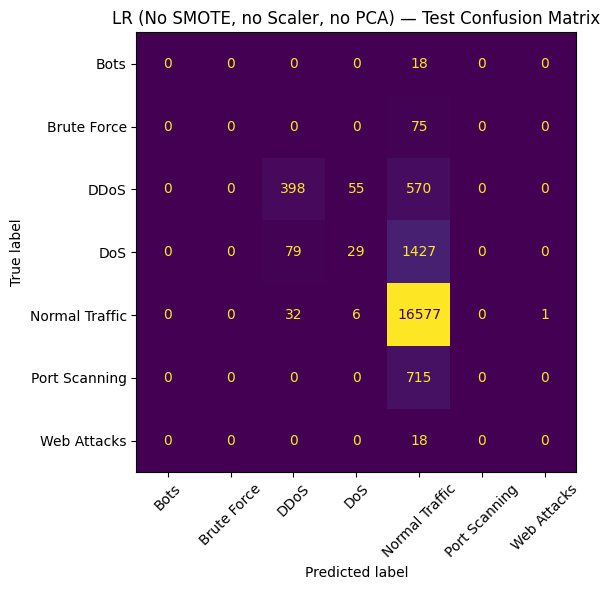


=== LR (No SMOTE, no Scaler, no PCA) ===
Best params: {}
Validation acc: 0.8514, f1: 0.2145
Test acc: 0.8502, f1: 0.2108
                precision    recall  f1-score   support

          Bots      0.000     0.000     0.000        18
   Brute Force      0.000     0.000     0.000        75
          DDoS      0.782     0.389     0.520      1023
           DoS      0.322     0.019     0.036      1535
Normal Traffic      0.854     0.998     0.921     16616
 Port Scanning      0.000     0.000     0.000       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.850     20000
     macro avg      0.280     0.201     0.211     20000
  weighted avg      0.775     0.850     0.794     20000



c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [58]:
all_results.append(run_experiment(
    LogisticRegression(max_iter=3000, solver='lbfgs', random_state=42), 
    {},
    "LR (No SMOTE, no Scaler, no PCA)", 
    use_smote=False, 
    use_pca=False,
    use_scaler=False))

### Running the model without scaler using SMOTE and PCA

Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


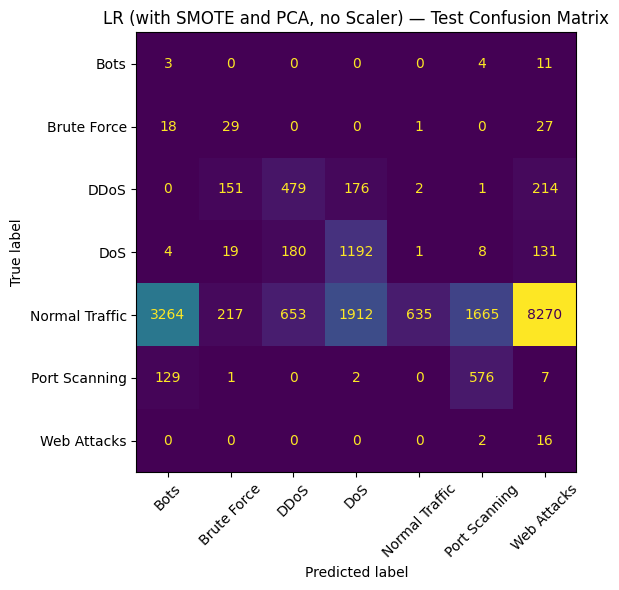


=== LR (with SMOTE and PCA, no Scaler) ===
Best params: {}
Validation acc: 0.1459, f1: 0.2141
Test acc: 0.1465, f1: 0.2128
                precision    recall  f1-score   support

          Bots      0.001     0.167     0.002        18
   Brute Force      0.070     0.387     0.118        75
          DDoS      0.365     0.468     0.410      1023
           DoS      0.363     0.777     0.495      1535
Normal Traffic      0.994     0.038     0.074     16616
 Port Scanning      0.255     0.806     0.388       715
   Web Attacks      0.002     0.889     0.004        18

      accuracy                          0.146     20000
     macro avg      0.293     0.504     0.213     20000
  weighted avg      0.882     0.146     0.134     20000



In [59]:
all_results.append(run_experiment(
    LogisticRegression(max_iter=3000, solver='lbfgs', random_state=42), 
    {},
    "LR (with SMOTE and PCA, no Scaler)", 
    use_smote=True, 
    use_pca=True,
    use_scaler=False))

#### **Conclusions**

Without scaling and SMOTE the model predicts 85% as "Normal Traffic", because the data is imbalanced. Also F1-macro is only 21%, which means that this model can't predict most of the Attack Types. Using SMOTE and PCA without scaling leads to misleading results. F1-macro decreased even more from 21% to 18% which highlights the critical role of scaling.

Max iterations were between 1000 and 3000 but the model still reached the number of iterations limit. Features have large difference in degree so this proves that StandardScaler is necessary for Logistic Regression so we can find a solution in descent amount of time.

### Running the model with SMOTE, scaling and PCA

Fitting 3 folds for each of 12 candidates, totalling 36 fits


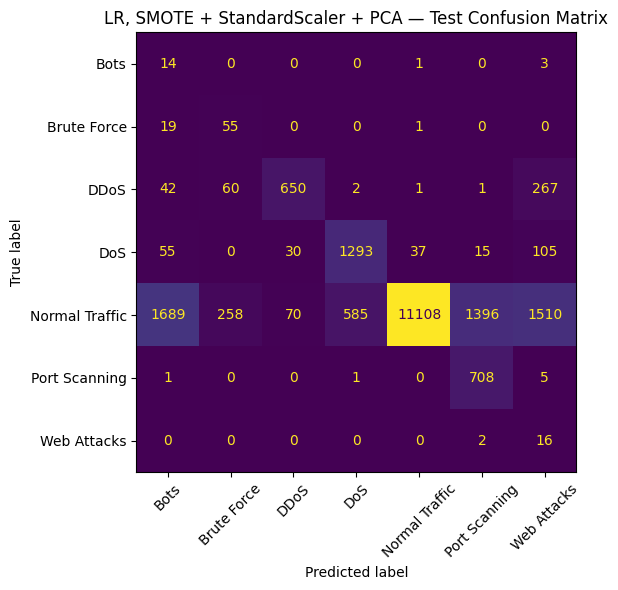


=== LR, SMOTE + StandardScaler + PCA ===
Best params: {'clf__C': 100.0, 'pca__n_components': 10}
Validation acc: 0.6917, f1: 0.4379
Test acc: 0.6922, f1: 0.4381
                precision    recall  f1-score   support

          Bots      0.008     0.778     0.015        18
   Brute Force      0.147     0.733     0.246        75
          DDoS      0.867     0.635     0.733      1023
           DoS      0.687     0.842     0.757      1535
Normal Traffic      0.996     0.669     0.800     16616
 Port Scanning      0.334     0.990     0.499       715
   Web Attacks      0.008     0.889     0.017        18

      accuracy                          0.692     20000
     macro avg      0.435     0.791     0.438     20000
  weighted avg      0.937     0.692     0.779     20000



In [60]:
# Parameters
lr_params = {
    'clf__C': [10.0, 50.0, 100.0],
    'pca__n_components': [4, 6, 8, 10]
}

# Running test (using the function created above)
# SMOTE + StandardScaler + PCA
all_results.append(run_experiment(
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42), 
    lr_params, "LR, SMOTE + StandardScaler + PCA",
    use_smote=True,
    use_scaler=True,
    use_pca=True))

### Running the same model as above but with PolynomialFeatures

Fitting 3 folds for each of 12 candidates, totalling 36 fits


c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


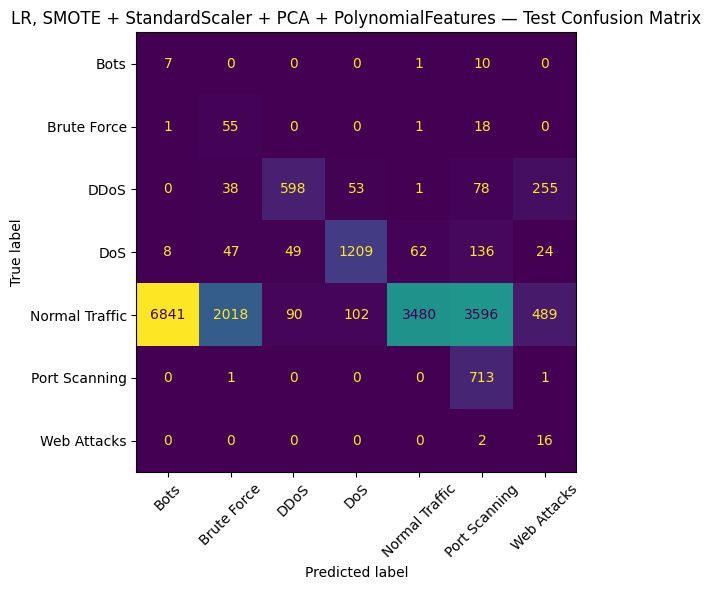


=== LR, SMOTE + StandardScaler + PCA + PolynomialFeatures ===
Best params: {'clf__C': 10.0, 'pca__n_components': 8}
Validation acc: 0.3057, f1: 0.3225
Test acc: 0.3039, f1: 0.3172
                precision    recall  f1-score   support

          Bots      0.001     0.389     0.002        18
   Brute Force      0.025     0.733     0.049        75
          DDoS      0.811     0.585     0.680      1023
           DoS      0.886     0.788     0.834      1535
Normal Traffic      0.982     0.209     0.345     16616
 Port Scanning      0.157     0.997     0.271       715
   Web Attacks      0.020     0.889     0.040        18

      accuracy                          0.304     20000
     macro avg      0.412     0.656     0.317     20000
  weighted avg      0.931     0.304     0.395     20000



In [61]:
all_results.append(run_experiment(
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42), 
    lr_params, "LR, SMOTE + StandardScaler + PCA + PolynomialFeatures",
    use_smote=True,
    use_scaler=True,
    use_pca=True,
    use_poly=True))

### Running the model using SMOTE and scaler, but no PCA

Fitting 3 folds for each of 4 candidates, totalling 12 fits


c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


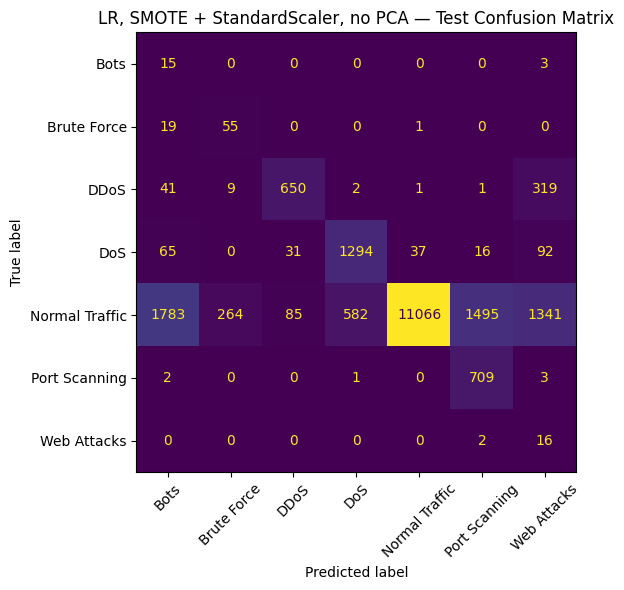


=== LR, SMOTE + StandardScaler, no PCA ===
Best params: {'clf__C': 100.0}
Validation acc: 0.6904, f1: 0.4380
Test acc: 0.6903, f1: 0.4389
                precision    recall  f1-score   support

          Bots      0.008     0.833     0.015        18
   Brute Force      0.168     0.733     0.273        75
          DDoS      0.849     0.635     0.727      1023
           DoS      0.689     0.843     0.758      1535
Normal Traffic      0.996     0.666     0.798     16616
 Port Scanning      0.319     0.992     0.483       715
   Web Attacks      0.009     0.889     0.018        18

      accuracy                          0.690     20000
     macro avg      0.434     0.799     0.439     20000
  weighted avg      0.936     0.690     0.777     20000



In [62]:
lr_params_no_pca = {
    'clf__C': [1.0, 10.0, 50.0, 100.0]
}

all_results.append(run_experiment(
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42), 
    lr_params_no_pca, "LR, SMOTE + StandardScaler, no PCA",
    use_pca=False))

### Running the model without SMOTE and using PCA

Fitting 3 folds for each of 12 candidates, totalling 36 fits


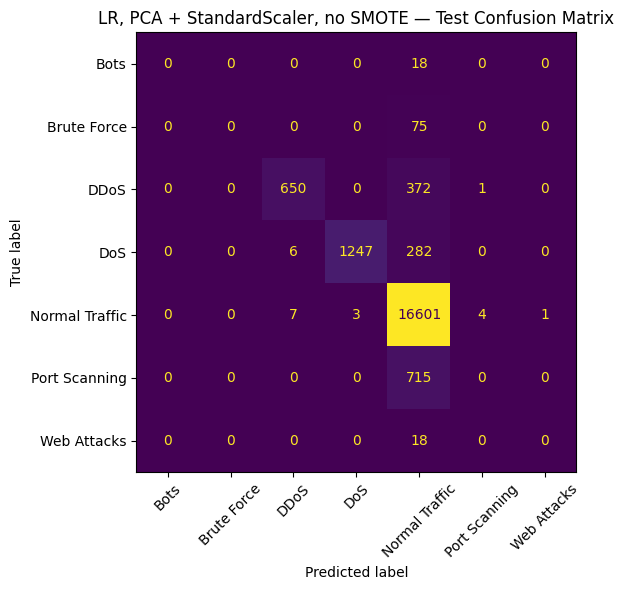


=== LR, PCA + StandardScaler, no SMOTE ===
Best params: {'clf__C': 100.0, 'pca__n_components': 10}
Validation acc: 0.9270, f1: 0.3783
Test acc: 0.9249, f1: 0.3748
                precision    recall  f1-score   support

          Bots      0.000     0.000     0.000        18
   Brute Force      0.000     0.000     0.000        75
          DDoS      0.980     0.635     0.771      1023
           DoS      0.998     0.812     0.896      1535
Normal Traffic      0.918     0.999     0.957     16616
 Port Scanning      0.000     0.000     0.000       715
   Web Attacks      0.000     0.000     0.000        18

      accuracy                          0.925     20000
     macro avg      0.414     0.350     0.375     20000
  weighted avg      0.890     0.925     0.903     20000



c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [63]:
all_results.append(run_experiment(
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42), 
    lr_params, "LR, PCA + StandardScaler, no SMOTE", 
    use_smote=False,
    use_scaler=True,
    use_pca=True))

### Running the model using SMOTE, StandardScaler and LDA

Fitting 3 folds for each of 4 candidates, totalling 12 fits


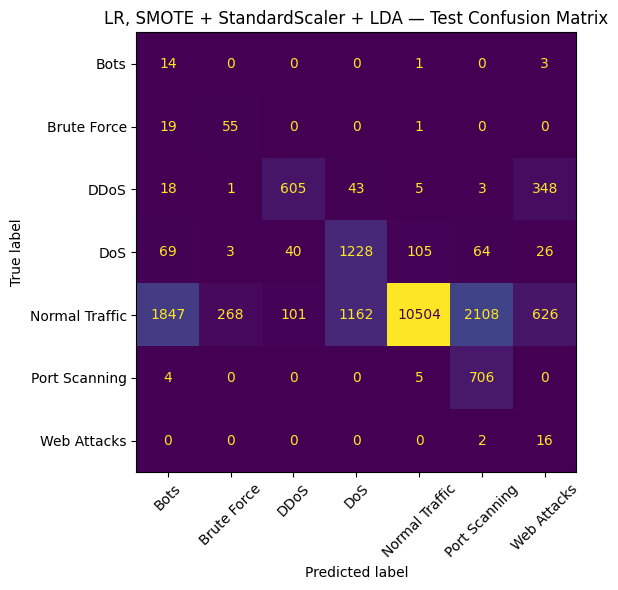


=== LR, SMOTE + StandardScaler + LDA ===
Best params: {'clf__C': 1.0}
Validation acc: 0.6539, f1: 0.3944
Test acc: 0.6564, f1: 0.3979
                precision    recall  f1-score   support

          Bots      0.007     0.778     0.014        18
   Brute Force      0.168     0.733     0.274        75
          DDoS      0.811     0.591     0.684      1023
           DoS      0.505     0.800     0.619      1535
Normal Traffic      0.989     0.632     0.771     16616
 Port Scanning      0.245     0.987     0.392       715
   Web Attacks      0.016     0.889     0.031        18

      accuracy                          0.656     20000
     macro avg      0.392     0.773     0.398     20000
  weighted avg      0.911     0.656     0.738     20000



In [64]:
all_results.append(run_experiment(
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42), 
    lr_params_no_pca, "LR, SMOTE + StandardScaler + LDA", 
    use_smote=True,
    use_scaler=True,
    use_lda=True,
    use_pca=False))

#### **Conclusions**

Running the Logistic Regression using the skeleton which has scaling and SMOTE changed the accuracy from 85% to 69%. Even though the overall accuracy is lower, after SMOTE the model predicts around 83% of Bots and 99% of Port Scanning attacks correctly. F1-macro increased from 21% to 42% with scaling and SMOTE so this model doubled the performance. Use of PCA didn't have remarkable affect on model's performance.

Although with SMOTE and scaling it has false alarms and it predicts some of Normal Traffic as attacks, it is more valuable to distinguish the actual attacks more accurately for security.

### Testing the effect of MinMaxScaler

Fitting 3 folds for each of 12 candidates, totalling 36 fits


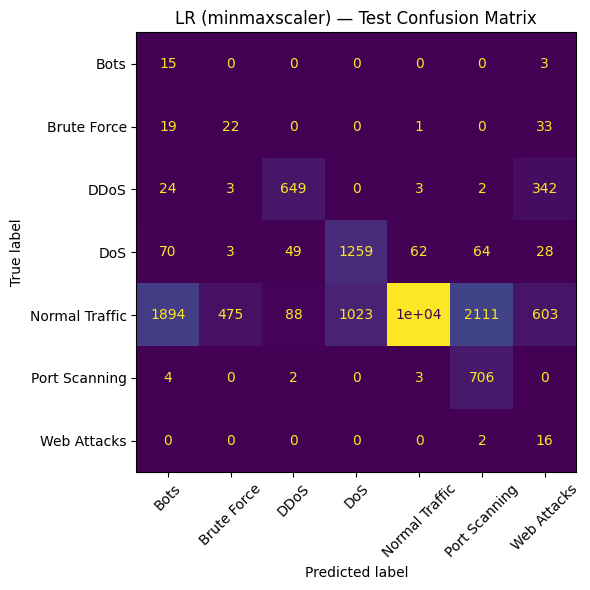


=== LR (minmaxscaler) ===
Best params: {'clf__C': 100.0, 'pca__n_components': 10}
Validation acc: 0.6576, f1: 0.3851
Test acc: 0.6544, f1: 0.3799
                precision    recall  f1-score   support

          Bots      0.007     0.833     0.015        18
   Brute Force      0.044     0.293     0.076        75
          DDoS      0.824     0.634     0.717      1023
           DoS      0.552     0.820     0.660      1535
Normal Traffic      0.993     0.627     0.769     16616
 Port Scanning      0.245     0.987     0.392       715
   Web Attacks      0.016     0.889     0.031        18

      accuracy                          0.654     20000
     macro avg      0.383     0.726     0.380     20000
  weighted avg      0.919     0.654     0.740     20000



In [65]:
# Testing with minmaxscaler (using seperately created method)
model_minmax = all_results.append(run_experiment_minmax
                                  (LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42),
                                    lr_params, "LR (minmaxscaler)"))

#### **Conclusions**

MinMaxScaler performed worse than StandardScaler. Overall accuracy decreased to around 62% when the StandardScaler had 69%. Also the recall for Brute Force and Bots decreased significantly. This is probably due to outliers and StandardScaler handles them more stable.

In [66]:
# Printing all the results
import pandas as pd
df_results = pd.DataFrame(all_results)
display(df_results)

,label,grid,best_params,val_acc,val_f1_macro,test_acc,test_f1_macro,smote,pca
0,"LR (No SMOTE, no Scaler, no PCA)","GridSearchCV(cv=3,\n estimator=Pip...",{},0.85135,0.214539,0.85020,0.210830,False,False
1,"LR (with SMOTE and PCA, no Scaler)","GridSearchCV(cv=3,\n estimator=Pip...",{},0.14585,0.214057,0.14650,0.212836,True,True
2,"LR, SMOTE + StandardScaler + PCA","GridSearchCV(cv=3,\n estimator=Pip...","{'clf__C': 100.0, 'pca__n_components': 10}",0.69175,0.437938,0.69220,0.438134,True,True
3,"LR, SMOTE + StandardScaler + PCA + PolynomialF...","GridSearchCV(cv=3,\n estimator=Pip...","{'clf__C': 10.0, 'pca__n_components': 8}",0.30570,0.322525,0.30390,0.317238,True,True
4,"LR, SMOTE + StandardScaler, no PCA","GridSearchCV(cv=3,\n estimator=Pip...",{'clf__C': 100.0},0.69040,0.438036,0.69025,0.438856,True,False
5,"LR, PCA + StandardScaler, no SMOTE","GridSearchCV(cv=3,\n estimator=Pip...","{'clf__C': 100.0, 'pca__n_components': 10}",0.92695,0.378325,0.92490,0.374783,False,True
6,"LR, SMOTE + StandardScaler + LDA","GridSearchCV(cv=3,\n estimator=Pip...",{'clf__C': 1.0},0.65385,0.394445,0.65640,0.397895,True,False
7,LR (minmaxscaler),"GridSearchCV(cv=3,\n estimator=Pip...","{'clf__C': 100.0, 'pca__n_components': 10}",0.65760,0.385102,0.65445,0.379867,True,True
